In [1]:
import os
from pathlib import Path
import sys
import numpy as np
import scvelo as scv

In [2]:
notebook_dir = os.getcwd()
notebook_dir

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github\\STVelo\\notebooks\\analysis\\performance_on_simulated_data'

In [3]:
Path(notebook_dir).parents[3]

WindowsPath('c:/Users/OmerCagatayTalikaci/Desktop/github')

In [4]:
os.chdir(Path(notebook_dir).parents[3])

In [5]:
stvelo_path = os.path.join(os.getcwd(),'STVelo','stvelo')

import sys  
sys.path.insert(1,stvelo_path)

from pipelines.metrics import *
from pipelines.utils import proportions_nuc_cyto

# Read adatas 

In [6]:
adata_folder_path = os.path.join(os.getcwd(), 'data', 'perf_sim_data3') 

In [7]:
import os
import anndata as ad


# Initialize an empty dictionary to store the AnnData objects
adata_dict = {}

# Loop through all files in the folder
for file_name in os.listdir(adata_folder_path):
    # Check if the file has .h5ad extension
    if file_name.endswith('.h5ad'):
        # Remove the file extension to use as the dictionary key
        key = os.path.splitext(file_name)[0]
        
        # Read the .h5ad file and store it in the dictionary
        adata_dict[key] = scv.read(os.path.join(adata_folder_path, file_name))

# Now, adata_dict contains the .h5ad files with keys as their filenames without extension


In [8]:
adatas = {k:v.copy() for k,v in adata_dict.items()}

In [9]:
adatas.keys()

dict_keys(['adata_n_c_2000obs_300genes_deterministic', 'adata_n_c_2000obs_300genes_dynamical', 'adata_n_c_2000obs_300genes_stochastic', 'adata_n_c_2000obs_300genes_velovi', 'adata_s_u_2000obs_300genes_deterministic', 'adata_s_u_2000obs_300genes_dynamical', 'adata_s_u_2000obs_300genes_stochastic', 'adata_s_u_2000obs_300genes_velovi'])

In [11]:
deterministic_dict = {k: v.copy() for k, v in adatas.items() if k.endswith('deterministic')}
dynamical_dict = {k: v.copy() for k, v in adatas.items() if k.endswith('dynamical')}
velovi_dict = {k: v.copy() for k, v in adatas.items() if k.endswith('velovi')}
stochastic_dict = {k: v.copy() for k, v in adatas.items() if k.endswith('stochastic')}

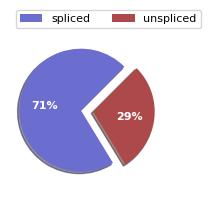

<Axes: >

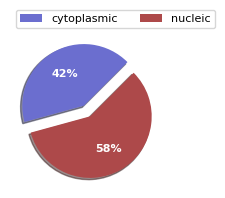

In [13]:
scv.pl.proportions(deterministic_dict['adata_s_u_2000obs_300genes_deterministic'])
proportions_nuc_cyto(adata_dict['adata_n_c_2000obs_300genes_deterministic'])

# Umaps 

In [14]:
import matplotlib.pyplot as plt 

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


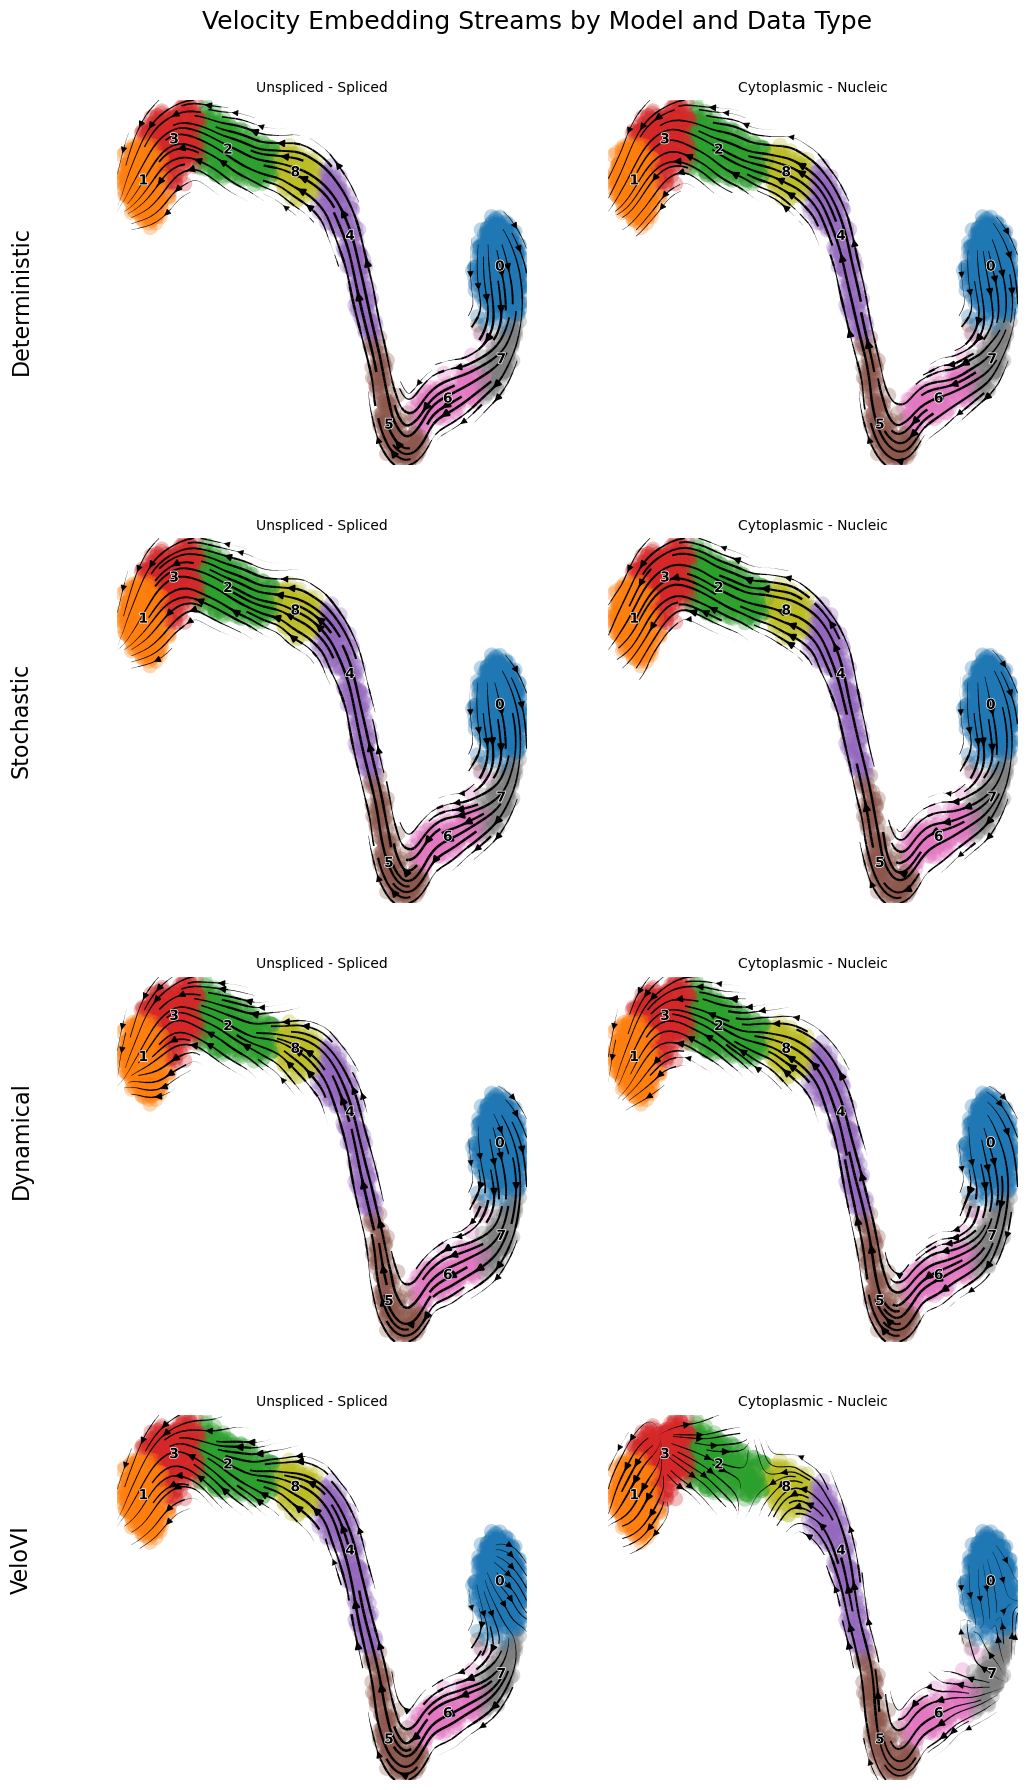

In [15]:
import matplotlib.pyplot as plt
import scvelo as scv

# Create a figure with 4 rows and 2 columns of subplots
fig, axes = plt.subplots(4, 2, figsize=(12, 20))  # Adjust figsize for better visibility

# List of velocity types and corresponding row labels
velocity_types = ['deterministic', 'stochastic', 'dynamical', 'velovi']
row_labels = ['Deterministic', 'Stochastic', 'Dynamical', 'VeloVI']

# Column titles
column_titles = ['Unspliced - Spliced', 'Cytoplasmic - Nucleic']

# Adjust subplot parameters to make room for row headings
plt.subplots_adjust(left=0.15, top=0.95)

# Loop over each velocity type and plot the corresponding subplots
for i, (velocity_type, row_label) in enumerate(zip(velocity_types, row_labels)):
    # Left column plot (Spliced-Unspliced)
    adata_key_su = f'adata_s_u_2000obs_300genes_{velocity_type}'
    scv.pl.velocity_embedding_stream(
        adata_dict[adata_key_su],
        basis='umap',
        color='leiden',
        ax=axes[i, 0],
        show=False,
        title=column_titles[0]
    )
    
    # Right column plot (Cytoplasmic-Nucleic)
    adata_key_nc = f'adata_n_c_2000obs_300genes_{velocity_type}'
    scv.pl.velocity_embedding_stream(
        adata_dict[adata_key_nc],
        basis='umap',
        color='leiden',
        ax=axes[i, 1],
        show=False,
        title=column_titles[1]
    )
    
    # Turn off y-axis labels to reduce clutter
    axes[i, 0].set_ylabel('')
    axes[i, 1].set_ylabel('')

# Add main headings for each row (velocity models)
for i, row_label in enumerate(row_labels):
    # Place text in the middle of the row
    fig.text(
        0.07,  # Adjust as needed for horizontal position
        (0.85 - (i * 0.21)),  # Adjust for vertical position
        row_label,
        ha='center',
        va='center',
        rotation='vertical',
        fontsize=16
    )

# Add a main title for the entire figure
fig.suptitle('Velocity Embedding Streams by Model and Data Type', fontsize=18, y=0.995)

# Adjust layout to prevent overlap
# plt.tight_layout(rect=[0.1, 0.025, 0.95, 0.95])

# Show the plot
plt.show()


In [16]:
import matplotlib.pyplot as plt
import scvelo as scv

def plot_velocity_embedding_streams(adata_dict, color_option='true_t'):
    """
    Plots velocity embedding streams for an AnnData dictionary with a specified color option.

    Parameters:
    - adata_dict (dict): Dictionary with AnnData objects. Keys should follow the pattern 
                         'adata_s_u_2000obs_300genes_{velocity_type}' and 
                         'adata_n_c_2000obs_300genes_{velocity_type}'.
    - color_option (str): Column name in AnnData.obs to color the plots. Default is 'true_t'.
    """
    # Create a figure with 4 rows and 2 columns of subplots
    fig, axes = plt.subplots(4, 2, figsize=(12, 20))  # Adjust figsize for better visibility

    # List of velocity types and corresponding row labels
    velocity_types = ['deterministic', 'stochastic', 'dynamical', 'velovi']
    row_labels = ['Deterministic', 'Stochastic', 'Dynamical', 'VeloVI']

    # Column titles
    column_titles = ['Unspliced - Spliced', 'Cytoplasmic - Nucleic']

    # Adjust subplot parameters to make room for row headings
    plt.subplots_adjust(left=0.15, top=0.95)

    # Loop over each velocity type and plot the corresponding subplots
    for i, (velocity_type, row_label) in enumerate(zip(velocity_types, row_labels)):
        # Left column plot (Unspliced-Spliced)
        adata_key_su = f'adata_s_u_2000obs_300genes_{velocity_type}'
        if adata_key_su in adata_dict:
            scv.pl.velocity_embedding_stream(
                adata_dict[adata_key_su],
                basis='umap',
                color=color_option,
                ax=axes[i, 0],
                show=False,
                title=column_titles[0]
            )

        # Right column plot (Cytoplasmic-Nucleic)
        adata_key_nc = f'adata_n_c_2000obs_300genes_{velocity_type}'
        if adata_key_nc in adata_dict:
            scv.pl.velocity_embedding_stream(
                adata_dict[adata_key_nc],
                basis='umap',
                color=color_option,
                ax=axes[i, 1],
                show=False,
                title=column_titles[1]
            )

        # Turn off y-axis labels to reduce clutter
        axes[i, 0].set_ylabel('')
        axes[i, 1].set_ylabel('')

    # Add main headings for each row (velocity models)
    for i, row_label in enumerate(row_labels):
        # Place text in the middle of the row
        fig.text(
            0.07,  # Adjust as needed for horizontal position
            (0.85 - (i * 0.21)),  # Adjust for vertical position
            row_label,
            ha='center',
            va='center',
            rotation='vertical',
            fontsize=16
        )

    # Add a main title for the entire figure
    fig.suptitle('Velocity Embedding Streams by Model and Data Type', fontsize=18, y=0.995)

    # Adjust layout to prevent overlap
    # plt.tight_layout(rect=[0.1, 0.025, 0.95, 0.95])

    # Show the plot
    plt.show()



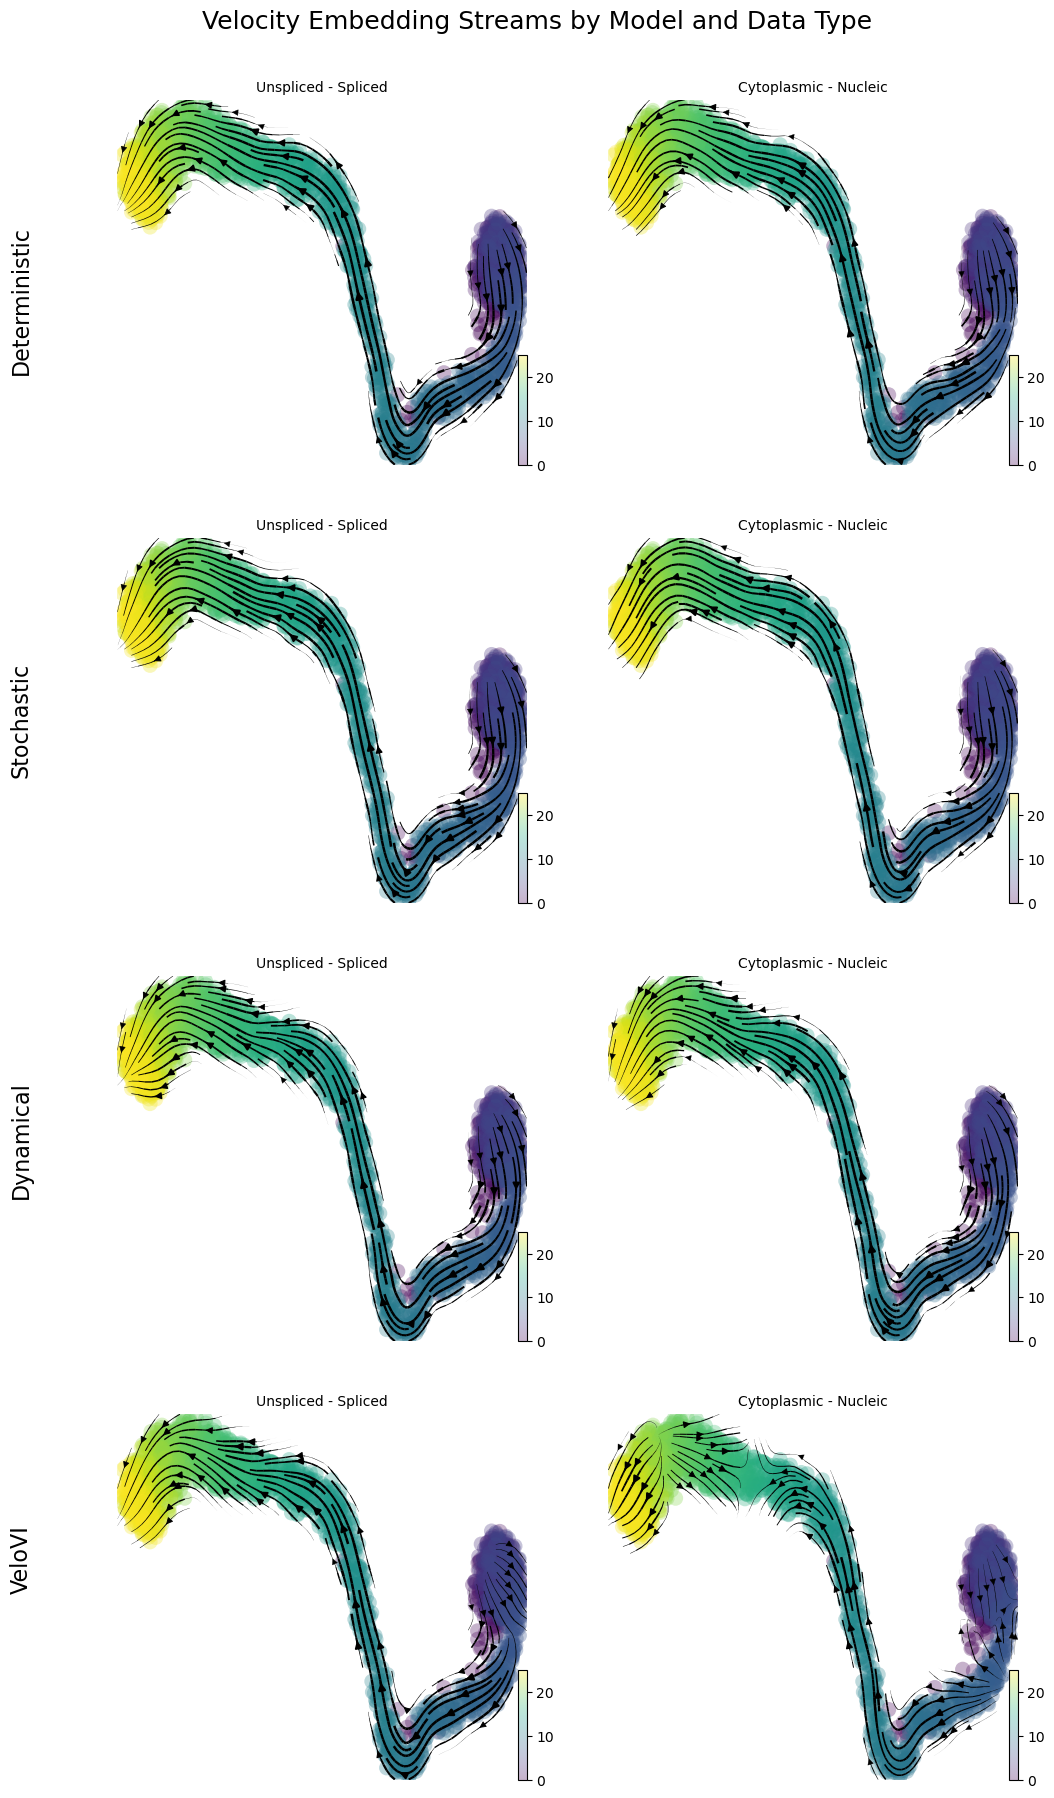

In [17]:
plot_velocity_embedding_streams(adata_dict=adata_dict,color_option='true_t')

# Metrics 

## Velocity Confidence


- Confidence metric measures the mean velocity consistency by calculating the pearson correlation between a cell and its neighbours. Let $v(x_j)$ be the velocity of cell $x_j$. Confidence $c_j$ is given by;

$$c_j = \frac{1}{k} \sum_{x \in \mathit{N_k(x_j)} } corr(v(x_j),v(x))$$

where $\mathit{N_k(x_j)}$ is the k-neighbours of $x_j$ in KNN graph.

In [18]:
import scvelo as scv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_velocity_confidences(adatas):
    """
    Computes velocity confidences for each AnnData object in the dictionary and plots them using a violin plot.

    Parameters:
    - adatas (dict): Dictionary where keys are in the format 'adata_type_obs_genes_velocitytype', 
                     and values are AnnData objects.

    The keys should follow this format:
    - 'adata_n_c_800obs_300genes_deterministic' or
      'adata_s_u_2000obs_300genes_deterministic'
    """
    
    # Initialize an empty list to collect data for plotting
    plot_data = []

    # Loop through each AnnData object in the dictionary
    for key, adata in adatas.items():
        # Compute velocity confidence
        scv.tl.velocity_confidence(adata)

        # Extract velocity confidences from adata.obs
        velocity_confidence = adata.obs['velocity_confidence'].values
        velocity_length = adata.obs['velocity_length'].values
        velocity_confidence_transition = adata.obs['velocity_confidence_transition'].values

        # Parse the key to extract metadata
        # Key format: 'adata_n_c_2000obs_300genes_deterministic'
        parts = key.split('_')
        data_type = parts[1] + '_' + parts[2]  # e.g., 'n_c' or 's_u'
        obs_count = parts[3]  # e.g., '2000obs'
        gene_count = parts[4]  # e.g., '300genes'
        velocity_type = parts[-1]  # e.g., 'deterministic', 'stochastic', 'dynamical', 'velovi'

        # Map data_type to full names
        data_type_map = {'n_c': 'cytoplasmic-nucleic', 's_u': 'spliced-unspliced'}
        data_type_full = data_type_map.get(data_type, data_type)

        # Map velocity_type to capitalized labels
        velocity_type_map = {
            'deterministic': 'Deterministic',
            'stochastic': 'Stochastic',
            'dynamical': 'Dynamical',
            'velovi': 'VeloVI'
        }
        velocity_type_label = velocity_type_map.get(velocity_type, velocity_type.capitalize())

        # Create a DataFrame for this adata
        df = pd.DataFrame({
            'velocity_confidence': velocity_confidence,
            'velocity_length': velocity_length,
            'velocity_confidence_transition': velocity_confidence_transition,
            'data_type': data_type_full,
            'obs_count': obs_count,
            'gene_count': gene_count,
            'velocity_type': velocity_type,
            'velocity_type_label': velocity_type_label
        })

        # Append to the list
        plot_data.append(df)

    # Concatenate all DataFrames into one
    plot_df = pd.concat(plot_data, ignore_index=True)

    # Define the order of velocity types
    velocity_type_order = ['deterministic', 'stochastic', 'dynamical', 'velovi']
    # Corresponding labels
    velocity_type_labels = ['Deterministic', 'Stochastic', 'Dynamical', 'VeloVI']
    # Map velocity_type to labels
    velocity_type_label_map = dict(zip(velocity_type_order, velocity_type_labels))

    # Map velocity_type to categorical type with specified order
    plot_df['velocity_type'] = pd.Categorical(
        plot_df['velocity_type'],
        categories=velocity_type_order,
        ordered=True
    )
    # Ensure the labels are in the same order
    plot_df['velocity_type_label'] = pd.Categorical(
        plot_df['velocity_type_label'],
        categories=velocity_type_labels,
        ordered=True
    )

    # Now, plot using seaborn
    # sns.set(style="whitegrid")

    # Create a color palette for data types
    data_types = plot_df['data_type'].unique()
    # Specify colors you want to use
    custom_palette = ['#1f77b4', '#ff7f0e']  # Example colors: blue and orange
    palette_dict = dict(zip(data_types, custom_palette))

    # Plot the violin plot
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.violinplot(
        x='velocity_type_label', 
        y='velocity_confidence', 
        hue='data_type', 
        data=plot_df, 
        palette=palette_dict, 
        split=False,
        # scale='width',
        # inner='quartile',
        order=velocity_type_labels,
        ax=ax
    )

    # Add vertical lines to separate velocity types
    x_positions = ax.get_xticks()
    for x in x_positions[1:]:
        ax.axvline(x=x - 0.5, color='gray', linestyle='--', linewidth=1)

    # Adjust legend labels
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, title='Data Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title('Velocity Confidence by RNA Velocity Model ')
    plt.xlabel('RNA Velocity Model')
    plt.ylabel('Velocity Confidence')
    plt.tight_layout()
    plt.show()


--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
--> added 'velocity_length'

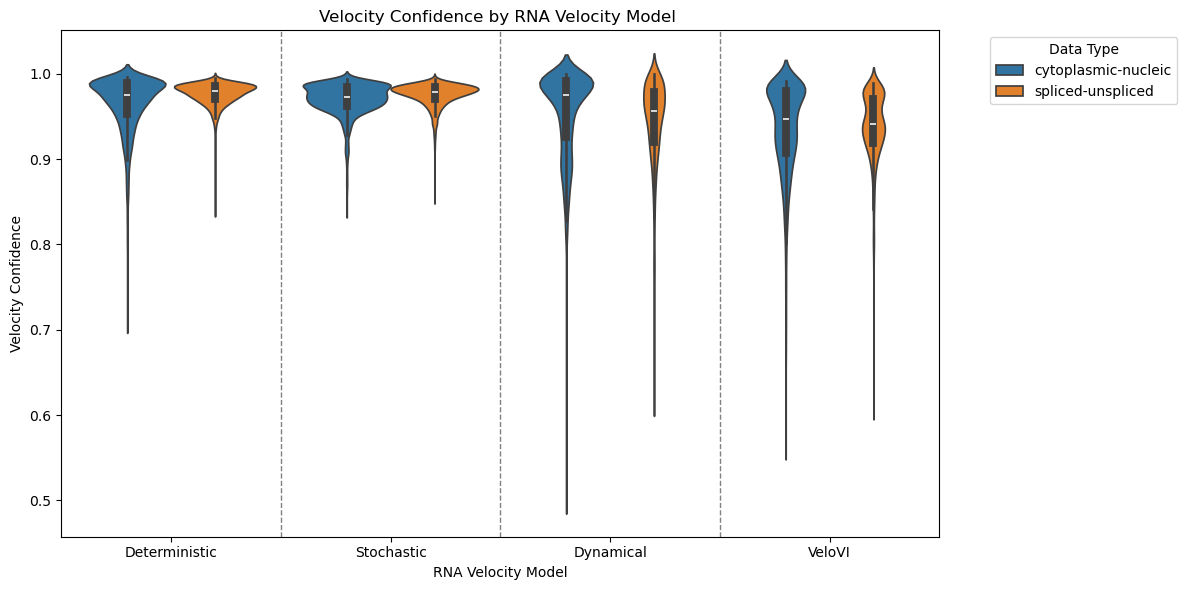

In [19]:
plot_velocity_confidences(adata_dict)

## velocity Correlations (by_gene)

In [20]:
import scvelo as scv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import ma

def compute_velocity_correlations(adatas, mode='by_gene'):
    """
    Computes the correlation between velocity matrices of the same velocity type but different data types (n_c vs s_u).

    Parameters:
    - adatas (dict): Dictionary where keys are in the format 'adata_type_obs_genes_velocitytype',
                     and values are AnnData objects.
    - mode (str): 'by_gene' or 'by_cell' to specify the axis along which to compute the correlations.

    Returns:
    - correlations (dict): A dictionary with velocity types as keys and lists of correlation coefficients as values.
    """

    # Collect all unique velocity types
    velocity_types = set()
    for key in adatas.keys():
        parts = key.split('_')
        velocity_type = parts[-1]  # e.g., 'deterministic', 'stochastic', 'dynamical', 'velovi'
        velocity_types.add(velocity_type)

    correlations = {}  # Dictionary to store correlations for each velocity type

    for velocity_type in velocity_types:
        print(velocity_type)
        # Find the corresponding AnnData objects for n_c and s_u
        key_n_c = None
        key_s_u = None
        for key in adatas.keys():
            if key.endswith(velocity_type):
                if '_n_c_' in key:
                    key_n_c = key
                elif '_s_u_' in key:
                    key_s_u = key
        if key_n_c and key_s_u:
            adata_n_c = adatas[key_n_c]
            adata_s_u = adatas[key_s_u]

            # Ensure that the velocity matrices are computed
            if 'velocity' not in adata_n_c.layers or 'velocity' not in adata_s_u.layers:
                print(f"Velocity not found in {key_n_c} or {key_s_u}. Skipping.")
                continue

            # Extract the velocity matrices
            velo_n_c = pd.DataFrame(
                adata_n_c.layers['velocity'], 
                index=adata_n_c.obs_names, 
                columns=adata_n_c.var_names
            )
            velo_s_u = pd.DataFrame(
                adata_s_u.layers['velocity'], 
                index=adata_s_u.obs_names, 
                columns=adata_s_u.var_names
            )

            # Ensure that the DataFrames are aligned
            # velo_n_c = velo_n_c.sort_index().sort_index(axis=1)
            # velo_s_u = velo_s_u.sort_index().sort_index(axis=1)

            # Compute correlations
            if mode == 'by_cell':
                # Compute correlation by cell (across genes)
                cross_corrs = []
                for i in velo_n_c.index:
                    v1 = velo_n_c.loc[i].values
                    v2 = velo_s_u.loc[i].values
                    # Handle NaNs
                    mask = ~np.isnan(v1) & ~np.isnan(v2)
                    if np.sum(mask) > 0:
                        corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                        cross_corrs.append(corr)
                correlations[velocity_type] = cross_corrs
            elif mode == 'by_gene':
                # Compute correlation by gene (across cells)
                cross_corrs = []
                for gene in velo_n_c.columns:
                    v1 = velo_n_c[gene].values
                    v2 = velo_s_u[gene].values
                    # Handle NaNs
                    mask = ~np.isnan(v1) & ~np.isnan(v2)
                    if np.sum(mask) > 0:
                        corr = np.corrcoef(v1[mask], v2[mask])[0, 1]
                        cross_corrs.append(corr)
                correlations[velocity_type] = cross_corrs
            else:
                print(f"Unknown mode: {mode}. Use 'by_gene' or 'by_cell'.")
                return None
        else:
            print(f"Could not find matching n_c and s_u AnnData objects for velocity type {velocity_type}.")
    return correlations


In [21]:
def plot_velocity_correlations(correlations):
    """
    Plots box plots of the correlations calculated for each velocity type.

    Parameters:
    - correlations (dict): Dictionary with velocity types as keys and lists of correlation coefficients as values.
    """
    # Prepare the data for plotting
    plot_data = []
    for velocity_type, corr_values in correlations.items():
        # Map velocity_type to capitalized labels
        velocity_type_map = {
            'deterministic': 'Deterministic',
            'stochastic': 'Stochastic',
            'dynamical': 'Dynamical',
            'velovi': 'VeloVI'
        }
        velocity_type_label = velocity_type_map.get(velocity_type, velocity_type.capitalize())

        df = pd.DataFrame({
            'Correlation': corr_values,
            'Velocity Type': velocity_type_label
        })
        plot_data.append(df)

    # Concatenate all DataFrames
    plot_df = pd.concat(plot_data, ignore_index=True)

    # Define the order of velocity types
    velocity_type_order = ['Deterministic', 'Stochastic', 'Dynamical', 'VeloVI']

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        x='Velocity Type',
        y='Correlation',
        data=plot_df,
        order=velocity_type_order,
        palette='Set2'
    )
    sns.stripplot(
        x='Velocity Type',
        y='Correlation',
        data=plot_df,
        order=velocity_type_order,
        color='black',
        size=3,
        jitter=True,
        alpha=0.5
    )
    plt.title('Correlation between n_c and s_u Velocity Matrices by Velocity Model')
    plt.xlabel('Velocity Model')
    plt.ylabel('Correlation Coefficient')
    plt.tight_layout()
    plt.show()


In [22]:
cor = compute_velocity_correlations(adata_dict)

velovi
deterministic
stochastic
dynamical


In [ ]:
adata_dict['adata_n_c_2000obs_300genes_dynamical'].layers['velocity']

array([[ 3.47393338,         nan,  8.01469093, ...,         nan,
         0.19681224,         nan],
       [ 1.8372862 ,         nan,  2.0946868 , ...,         nan,
         0.26514821,         nan],
       [ 3.56581986,         nan,  5.06988844, ...,         nan,
         0.28947061,         nan],
       ...,
       [-1.97938105,         nan, -3.81853608, ...,         nan,
         0.20867933,         nan],
       [-1.91839265,         nan, -3.95841301, ...,         nan,
         0.20941709,         nan],
       [-1.8909262 ,         nan, -3.87146737, ...,         nan,
         0.23105388,         nan]])

In [33]:
len(cor['dynamical'])

109

In [30]:
corr_df_gene = pd.DataFrame(cor)
# corr_df_gene.reset_index(inplace=True)
true_t = list(adata_dict['adata_n_c_2000obs_300genes_dynamical'].var['true_t_'])
corr_df_gene['true_t'] = true_t

ValueError: All arrays must be of the same length

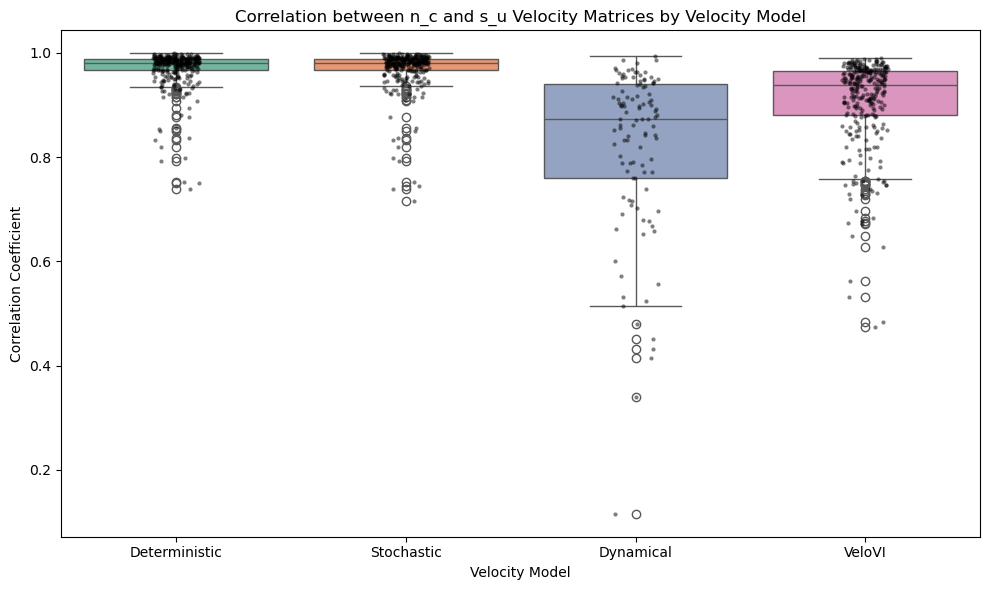

In [25]:
plot_velocity_correlations(cor)

In [34]:
corr_df_gene

,deterministic,velovi,dynamical,stochastic,true_t
0,0.820912,0.811798,0.455411,0.843671,38.232634
1,0.898957,0.928204,0.828578,0.914217,48.473325
2,0.931024,0.896453,0.931784,0.934411,41.504610
3,0.888889,0.936657,0.905649,0.886553,37.918060
4,0.579811,0.826703,0.718550,0.607149,30.329978
...,...,...,...,...,...
295,0.907115,0.940562,0.897044,0.910314,17.990758
296,0.800335,0.284324,0.660967,0.814805,10.190701
297,0.804752,0.777486,0.759442,0.806656,57.655704
298,0.838777,0.927581,-0.226168,0.840784,64.590633


In [202]:
pd.set_option('display.max_rows', 10)

In [35]:
corr_df_gene.sort_values('dynamical')

,deterministic,velovi,dynamical,stochastic,true_t
23,0.547570,0.744339,-0.966248,0.551582,52.476325
144,0.738033,0.755925,-0.960919,0.732727,54.159129
72,0.666496,0.899916,-0.958802,0.735051,64.735964
100,0.694861,0.686925,-0.724348,0.736305,46.066299
66,0.798161,0.768630,-0.685511,0.803092,55.048686
...,...,...,...,...,...
216,0.948601,0.718535,0.987714,0.964787,23.986548
167,0.973375,0.931403,0.988303,0.972982,26.292144
84,0.991137,0.958748,0.990000,0.992197,39.101023
158,0.966456,0.914942,0.994453,0.973691,29.457995


In [210]:
pd.set_option('display.max_rows', None)

In [36]:
import pandas as pd

# Assuming corr_df_gene is your DataFrame
# Sort the DataFrame by the 'dynamical' column
corr_df_gene_sorted = corr_df_gene.sort_values('dynamical')

# Create bins for the 'dynamical' column
num_bins = 5 # You can adjust the number of bins as needed
corr_df_gene_sorted['dynamical_bin'] = pd.cut(corr_df_gene_sorted['dynamical'], bins=num_bins)

# Group by the bins and calculate the mean of the 'true_t' column for each bin
mean_true_t_per_bin = corr_df_gene_sorted.groupby('dynamical_bin')['true_t'].mean()

# Print or display the result
print(mean_true_t_per_bin)


dynamical_bin
(-0.968, -0.574]    55.841017
(-0.574, -0.181]    51.590116
(-0.181, 0.211]     46.498457
(0.211, 0.604]      30.904018
(0.604, 0.996]      33.638777
Name: true_t, dtype: float64


In [235]:
pd.set_option('display.max_rows', 20)

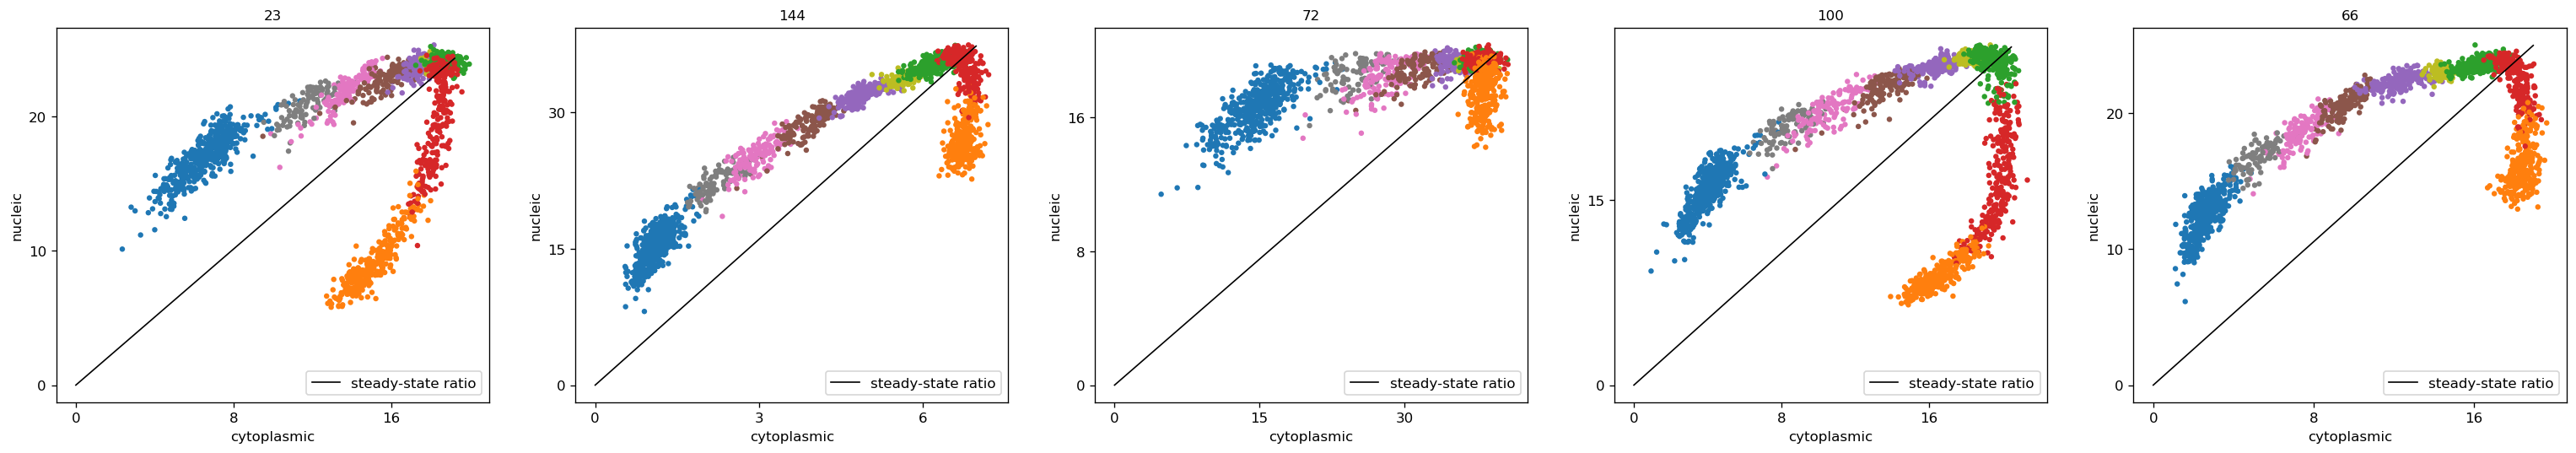

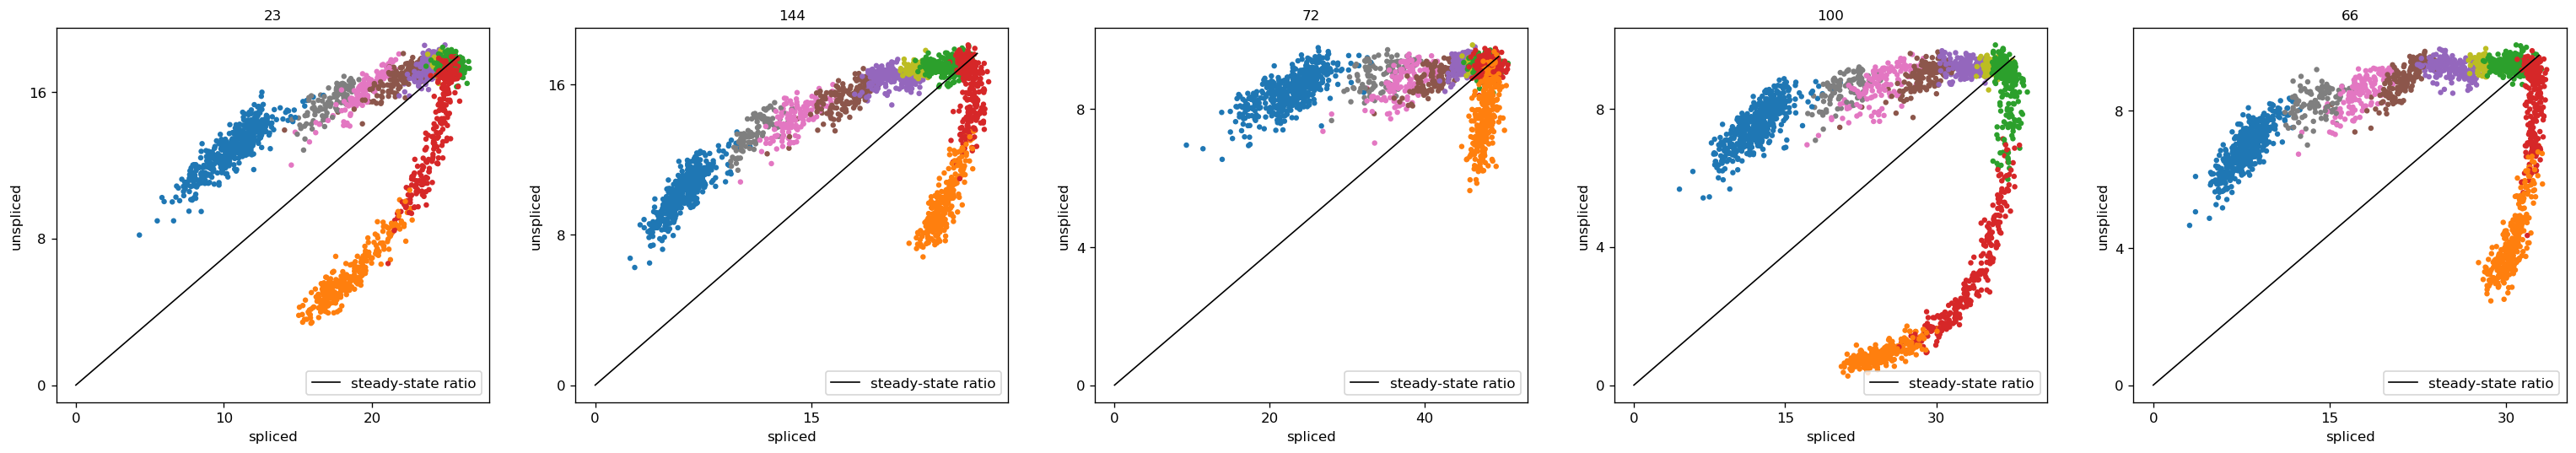

In [ ]:
scv.pl.scatter(adata_dict['adata_n_c_2000obs_300genes_deterministic'],color="leiden", basis=['23','144','72','100','66'], ncols=5, frameon=True,dpi=120, xlabel='cytoplasmic', ylabel='nucleic', vkey='velocity')
scv.pl.scatter(adata_dict['adata_s_u_2000obs_300genes_deterministic'],color="leiden", basis=['23','144','72','100','66'], ncols=5, frameon=True,dpi=120, vkey='velocity')

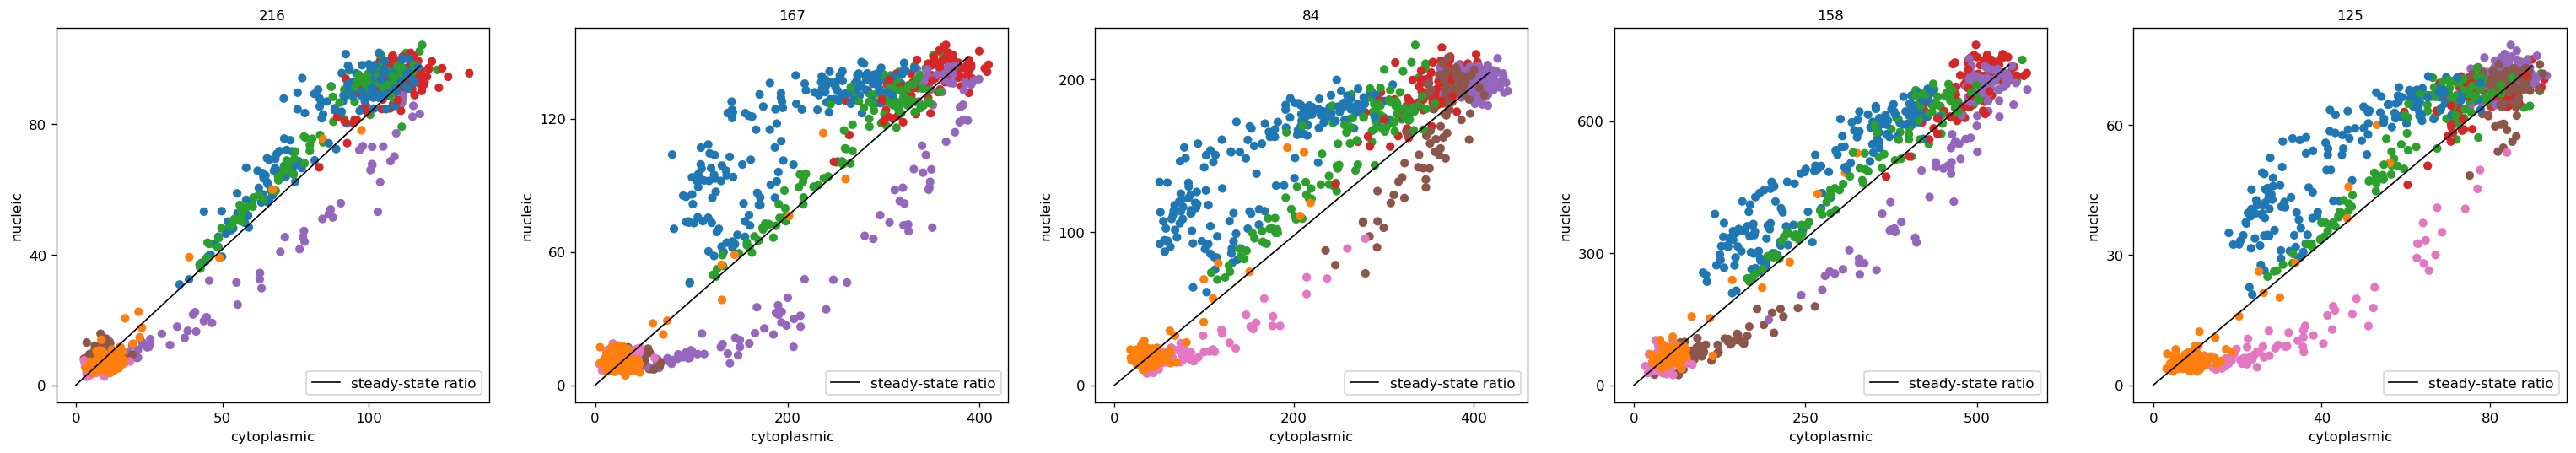

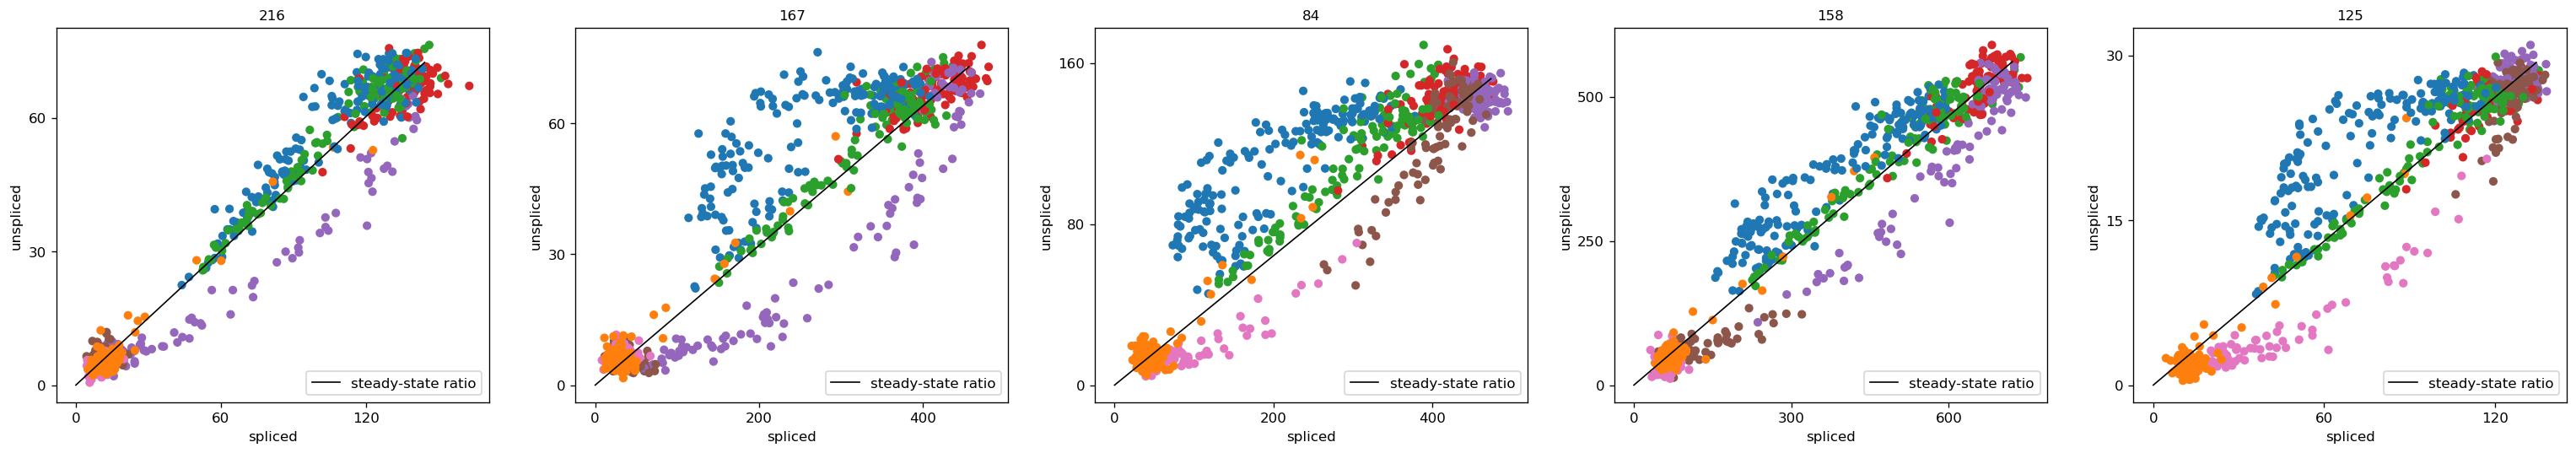

In [ ]:
scv.pl.scatter(adata_dict['adata_n_c_2000obs_300genes_deterministic'],color="leiden", basis=['216','167','84','158','125'], ncols=5, frameon=True,dpi=120, xlabel='cytoplasmic', ylabel='nucleic', vkey='velocity')
scv.pl.scatter(adata_dict['adata_s_u_2000obs_300genes_deterministic'],color="leiden", basis=['216','167','84','158','125'], ncols=5, frameon=True,dpi=120, vkey='velocity')

## Velocity Correlation by Cell

In [39]:
cor = compute_velocity_correlations(adata_dict,mode='by_cell')

deterministic
velovi
dynamical
stochastic


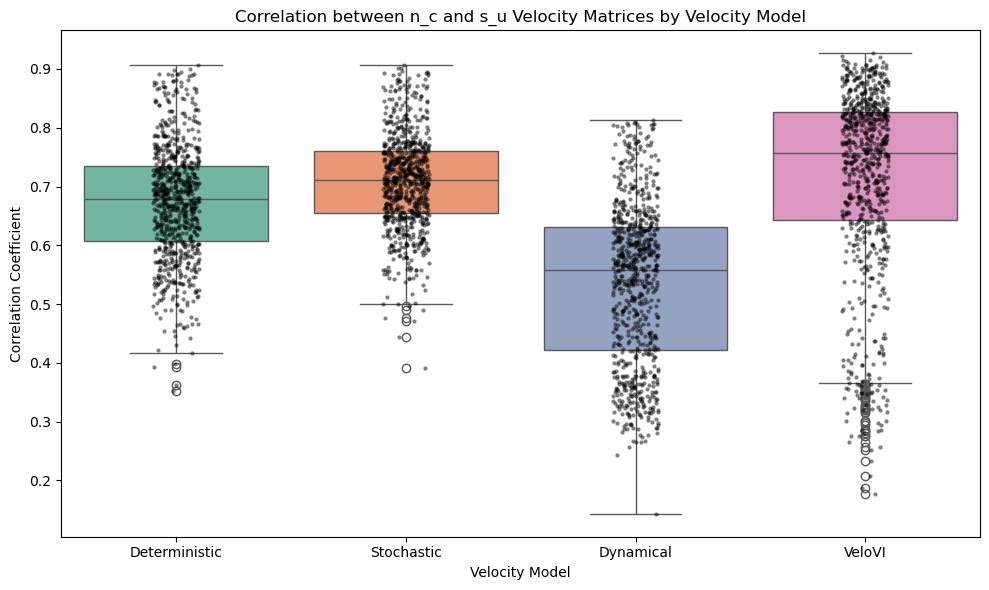

In [231]:
plot_velocity_correlations(cor)

In [ ]:
corr_df_cell = pd.DataFrame(cor)
# corr_df_gene.reset_index(inplace=True)
true_t = list(adata_dict['adata_n_c_2000obs_300genes_dynamical'].obs['true_t'])
leiden = list(adata_dict['adata_n_c_2000obs_300genes_dynamical'].obs['leiden'])
corr_df_cell['true_t'] = true_t
corr_df_cell['leiden'] = leiden

In [46]:
corr_df_cell.sort_values('dynamical')

,deterministic,velovi,dynamical,stochastic,true_t,leiden
386,0.548684,0.670372,0.143480,0.650783,38.40,5
392,0.416129,0.706460,0.243757,0.517759,38.64,5
97,0.721776,0.297705,0.257384,0.731371,7.09,2
644,0.544216,0.264973,0.264781,0.636155,65.61,1
779,0.701993,0.806685,0.265870,0.687752,80.87,2
...,...,...,...,...,...,...
6,0.829860,0.745930,0.806492,0.836819,0.42,0
33,0.892149,0.763515,0.808425,0.894563,2.03,0
30,0.890217,0.726342,0.808565,0.892996,1.80,0
28,0.891976,0.762015,0.810550,0.893157,1.79,0


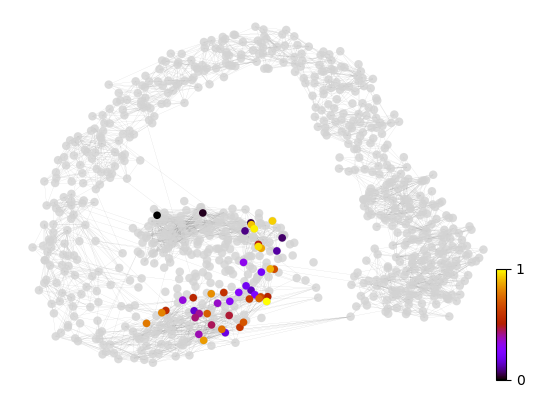

In [ ]:
x, y = scv.utils.get_cell_transitions(adata_dict['adata_s_u_2000obs_300genes_dynamical'], basis='umap', starting_cell=30)
ax = scv.pl.velocity_graph(adata_dict['adata_s_u_2000obs_300genes_dynamical'], c='lightgrey', edge_width=.05, show=False)
ax = scv.pl.scatter(adata_dict['adata_s_u_2000obs_300genes_dynamical'], x=x, y=y, s=120, c='ascending', cmap='gnuplot', ax=ax)

# Check the important genes 

In [58]:
for adata_name, adata in adata_dict.items():
    scv.tl.rank_velocity_genes(adata,groupby='leiden',min_corr=.3)

ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
   

In [40]:
scv.tl.rank_velocity_genes(adata_dict['adata_s_u_2000obs_300genes_dynamical'], groupby='leiden', min_corr=.3)
scv.tl.rank_velocity_genes(adata_dict['adata_n_c_2000obs_300genes_dynamical'], groupby='leiden', min_corr=.3)

ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)


In [41]:
dfs = scv.get_df(adata_dict['adata_s_u_2000obs_300genes_dynamical'].uns['rank_velocity_genes']['names'])
dfs.head(5)

,0,1,2,3,4,5,6,7,8
0,198,101,221,241,27,27,27,152,88
1,233,291,226,16,88,1,0,92,170
2,34,192,1,227,170,0,106,24,221
3,204,293,201,173,289,7,73,139,289
4,75,248,93,55,187,226,88,15,187


In [42]:
dfn = scv.get_df(adata_dict['adata_n_c_2000obs_300genes_dynamical'].uns['rank_velocity_genes']['names'])
dfn.head(5)

,0,1,2,3,4,5,6,7,8
0,204,69,277,149,13,13,270,298,277
1,198,255,151,55,287,273,298,270,151
2,16,108,149,151,273,116,273,7,170
3,87,234,226,126,277,270,116,79,35
4,14,293,201,152,149,298,7,171,187


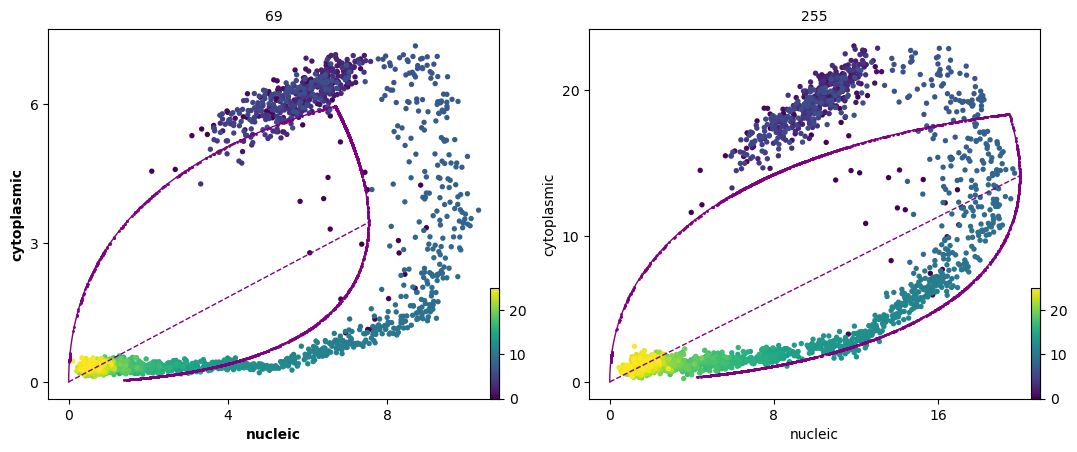

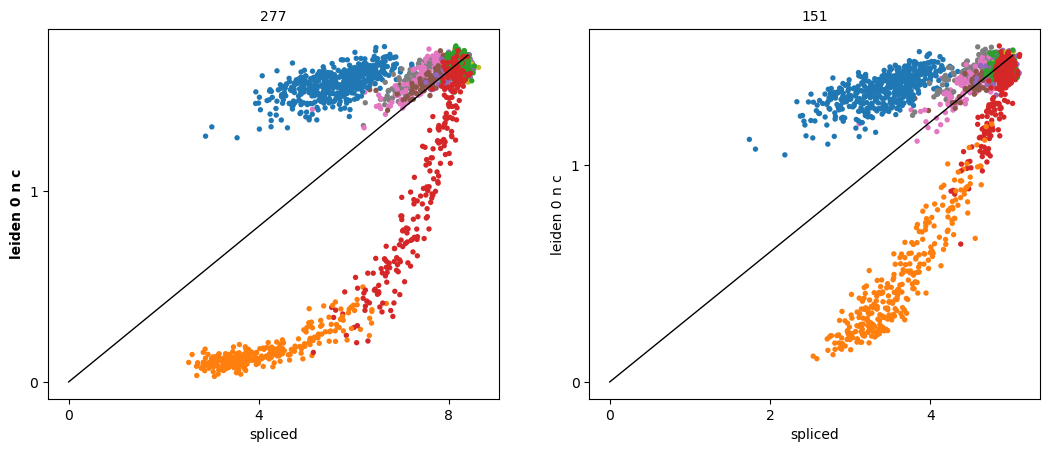

In [43]:
scv.pl.scatter(adata_dict['adata_n_c_2000obs_300genes_dynamical'], dfn['1'][:2], ylabel='cytoplasmic',xlabel='nucleic', color='true_t')
scv.pl.scatter(adata_dict['adata_s_u_2000obs_300genes_deterministic'], dfn['2'][:2], ylabel='leiden 0 n_c', color= 'leiden')

In [ ]:
adata_dict['adata_n_c_2000obs_300genes_deterministic']

AnnData object with n_obs × n_vars = 800 × 300
    obs: 'true_t', 'n_counts', 'leiden', 'velocity_self_transition'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'spearmans_score', 'velocity_score'
    uns: 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params', 'leiden_colors', 'rank_velocity_genes'
    obsm: 'X_pca', 'X_umap', 'velocity_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'spliced', 'spliced_nuc', 'true_velocity', 'unspliced', 'velocity'
    obsp: 'connectivities', 'distances'

In [ ]:
scv.tl.velocity_confidence(adata_dict['adata_n_c_2000obs_300genes_deterministic'])

--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)


### Compare all models

In [ ]:
adata_dict['adata_n_c_2000obs_300genes_velovi']

AnnData object with n_obs × n_vars = 800 × 300
    obs: 'true_t', 'n_counts', 'leiden', 'velocity_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'spearmans_score', 'velocity_score'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params', 'leiden_colors', 'rank_velocity_genes'
    obsm: 'X_pca', 'X_umap', 'velocity_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'fit_t', 'latent_time_velovi', 'spliced', 'spliced_nuc', 'true_velocity', 'unspliced', 'variance_velocity', 'velocity'
    obsp: 'connectivities', 'distances'

In [ ]:
cor_a = velocity_mean_correlation(adata_dict,mode='by_cell')
corr_by_gene = velocity_mean_correlation(adata_dict,mode='by_gene')

In [ ]:
name_mapping = {}

# Define data type mapping
data_type_map = {
    'n_c': 'in situ',
    's_u': 'splicing'
}

# Loop over each name in the index (and columns)
for name in cor_a.index:
    parts = name.split('_')
    # Extract data type (e.g., 'n_c' or 's_u')
    data_type = parts[1] + '_' + parts[2]
    data_type_label = data_type_map.get(data_type, data_type)
    
    # Extract velocity model (e.g., 'deterministic', 'stochastic', etc.)
    velocity_model = parts[5]
    # Capitalize the velocity model name
    velocity_model_label = velocity_model.capitalize()
    
    # Combine to form the new label
    new_label = f"{velocity_model_label} {data_type_label}"
    
    # Add to the mapping
    name_mapping[name] = new_label



In [89]:
# Rename the index and columns using the mapping
corr_by_cell = cor_a.rename(index=name_mapping, columns=name_mapping)
corr_by_gene = corr_by_gene.rename(index=name_mapping, columns=name_mapping)

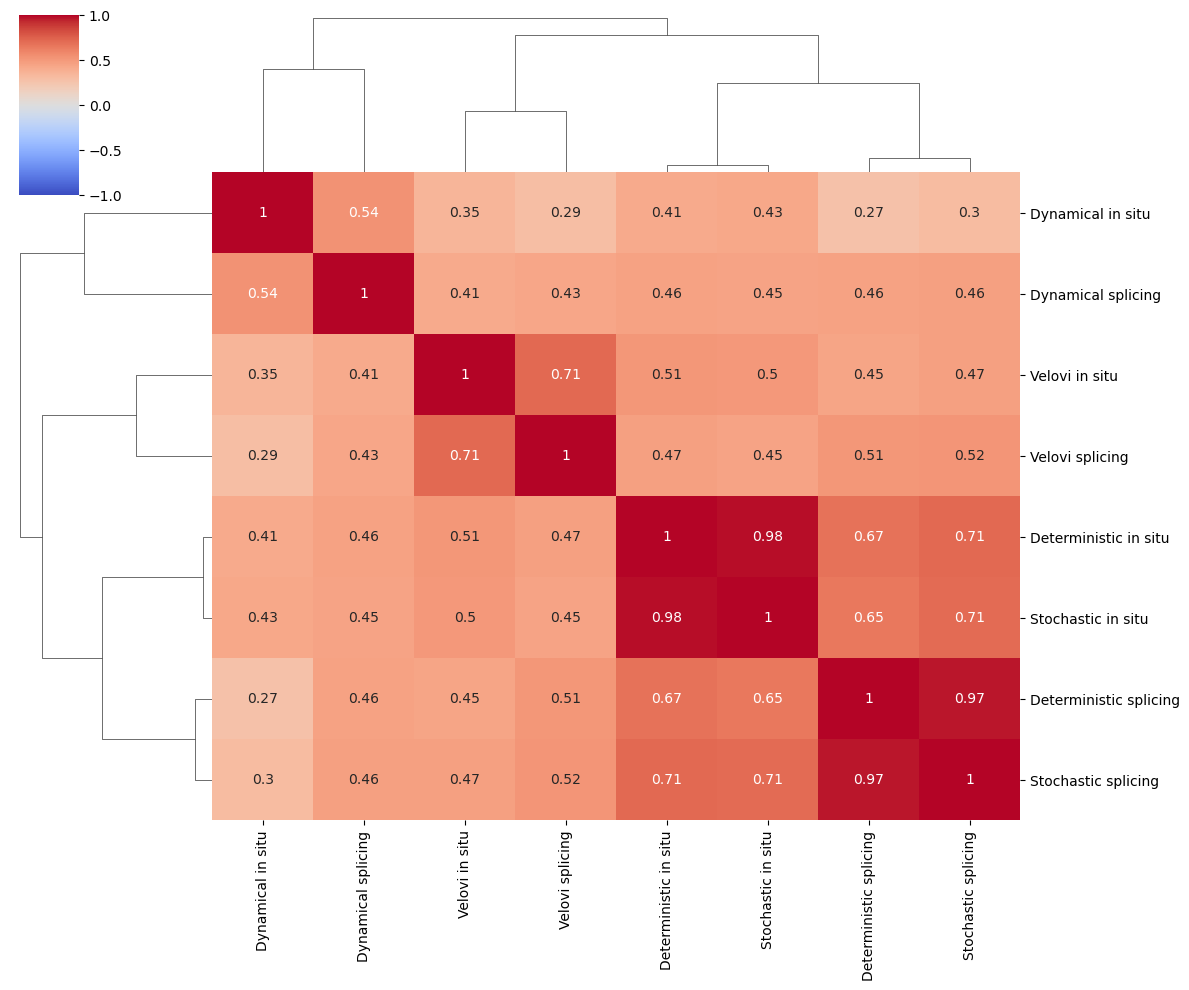

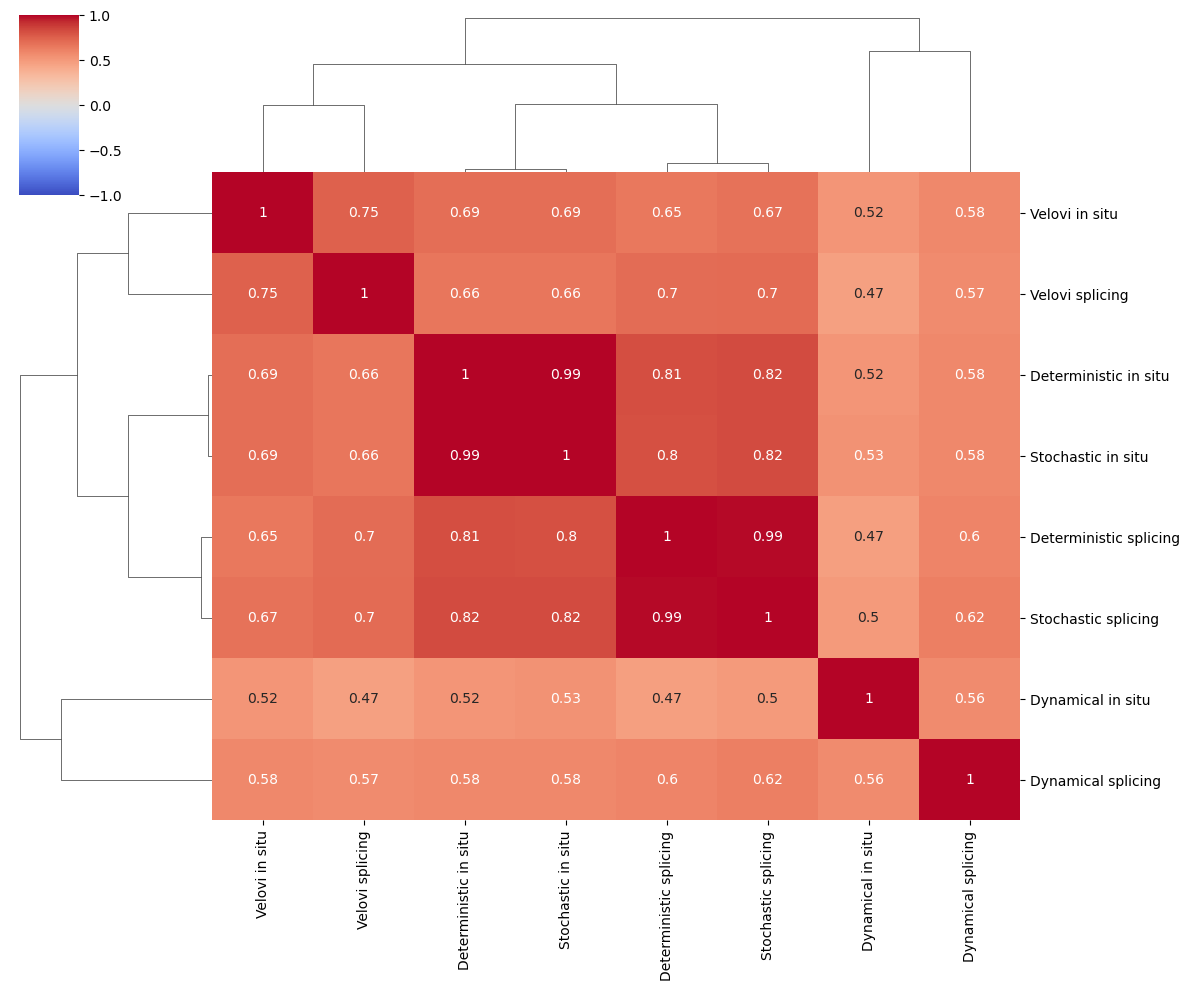

In [90]:
sns.clustermap(corr_by_cell, cmap='coolwarm', annot=True, figsize=(12, 10), vmin=-1, vmax=1)

sns.clustermap(corr_by_gene, cmap='coolwarm', annot=True, figsize=(12, 10), vmin=-1, vmax=1)

# Further plot for analysis- gene simulation 

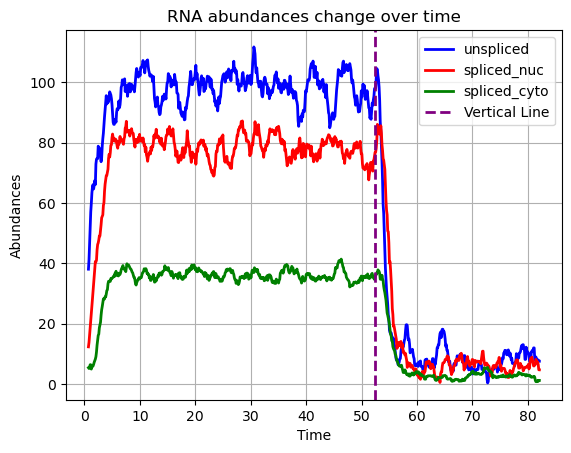

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Your sorted data arrays
unspliced = adata_dict['adata_n_c_2000obs_300genes_deterministic'].layers['unspliced'][:,23]- adata_dict['adata_n_c_2000obs_300genes_deterministic'].layers['spliced_nuc'][:,23] # Replace with your actual sorted data
spliced_nuc = adata_dict['adata_n_c_2000obs_300genes_deterministic'].layers['spliced_nuc'][:,23]
spliced_cyto = adata_dict['adata_n_c_2000obs_300genes_deterministic'].layers['spliced'][:,23]

# Assuming the x-values are indices or known values
x_values = np.arange(len(unspliced))
scaling_factor = 82.91 / 2000
x_values_scaled = x_values * scaling_factor

# Define a function for moving average smoothing
def moving_average(y, window_size):
    return np.convolve(y, np.ones(window_size)/window_size, mode='valid')

# Set the window size for smoothing
window_size = 15  # Adjust the window size as needed

# Calculate the moving averages for each dataset
smooth_data1 = moving_average(unspliced, window_size)
smooth_data2 = moving_average(spliced_nuc, window_size)
smooth_data3 = moving_average(spliced_cyto, window_size)

smooth_x_values = x_values[:len(smooth_data1)] + (window_size // 2)
smooth_x_values_scaled = smooth_x_values * scaling_factor

# Plot the scatter plots for each dataset using scaled x-values
# plt.scatter(x_values_scaled, data1, color='blue', marker='o', alpha=0.5, label='unspliced')
# plt.scatter(x_values_scaled, data2, color='red', marker='^', alpha=0.5, label='spliced_nuc')
# plt.scatter(x_values_scaled, data3, color='green', marker='s', alpha=0.5, label='spliced')

# Plot the smooth lines for each dataset using scaled x-values
plt.plot(smooth_x_values_scaled, smooth_data1, color='blue', linewidth=2, label='unspliced')
plt.plot(smooth_x_values_scaled, smooth_data2, color='red', linewidth=2, label='spliced_nuc')
plt.plot(smooth_x_values_scaled, smooth_data3, color='green', linewidth=2, label='spliced_cyto')


true_t = adata_dict['adata_n_c_2000obs_300genes_deterministic'].var['true_t_'][23] 


# Draw the vertical line using the scaled x-value
plt.axvline(x=true_t, color='purple', linestyle='--', linewidth=2, label='Vertical Line')

# Add labels and title
plt.xlabel('Time')
plt.ylabel('Abundances')
plt.title('RNA abundances change over time')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()


In [ ]:
54.159129	70.313750	1.904799	3.990005	3.548132	1.0	772	1.021699	1.021699	0.926665

In [227]:
70/3.5

20.0

In [226]:
70/4

17.5

In [225]:
70/1.9

36.8421052631579

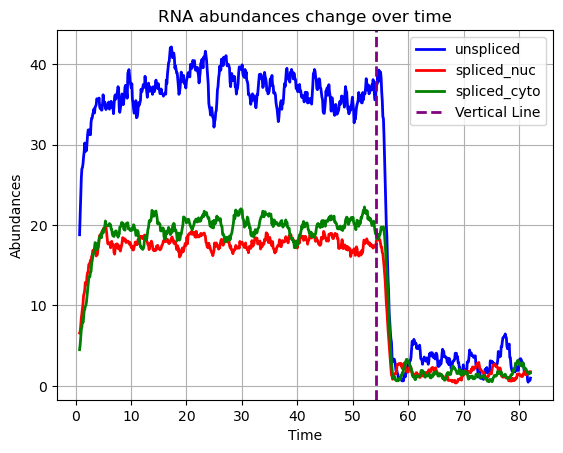

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Your sorted data arrays
unspliced = adata_dict['adata_s_u_2000obs_300genes_deterministic'].layers['unspliced'][:,144]
spliced_nuc = adata_dict['adata_s_u_2000obs_300genes_deterministic'].layers['spliced'][:,144]- adata_dict['adata_s_u_2000obs_300genes_deterministic'].layers['spliced_cyt'][:,144] 
spliced_cyto = adata_dict['adata_s_u_2000obs_300genes_deterministic'].layers['spliced_cyt'][:,144]# Replace with your actual sorted data

# Assuming the x-values are indices or known values
x_values = np.arange(len(unspliced))
scaling_factor = 82.91 / 2000
x_values_scaled = x_values * scaling_factor

# Define a function for moving average smoothing
def moving_average(y, window_size):
    return np.convolve(y, np.ones(window_size)/window_size, mode='valid')

# Set the window size for smoothing
window_size = 15  # Adjust the window size as needed

# Calculate the moving averages for each dataset
smooth_data1 = moving_average(unspliced, window_size)
smooth_data2 = moving_average(spliced_nuc, window_size)
smooth_data3 = moving_average(spliced_cyto, window_size)

smooth_x_values = x_values[:len(smooth_data1)] + (window_size // 2)
smooth_x_values_scaled = smooth_x_values * scaling_factor

# Plot the scatter plots for each dataset using scaled x-values
# plt.scatter(x_values_scaled, data1, color='blue', marker='o', alpha=0.5, label='unspliced')
# plt.scatter(x_values_scaled, data2, color='red', marker='^', alpha=0.5, label='spliced_nuc')
# plt.scatter(x_values_scaled, data3, color='green', marker='s', alpha=0.5, label='spliced')

# Plot the smooth lines for each dataset using scaled x-values
plt.plot(smooth_x_values_scaled, smooth_data1, color='blue', linewidth=2, label='unspliced')
plt.plot(smooth_x_values_scaled, smooth_data2, color='red', linewidth=2, label='spliced_nuc')
plt.plot(smooth_x_values_scaled, smooth_data3, color='green', linewidth=2, label='spliced_cyto')


true_t = adata_dict['adata_n_c_2000obs_300genes_deterministic'].var['true_t_'][144] 


# Draw the vertical line using the scaled x-value
plt.axvline(x=true_t, color='purple', linestyle='--', linewidth=2, label='Vertical Line')

# Add labels and title
plt.xlabel('Time')
plt.ylabel('Abundances')
plt.title('RNA abundances change over time')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()


In [ ]:
adata = adata_dict['adata_n_c_2000obs_300genes_dynamical']
adata_2 = adata_dict['adata_n_c_2000obs_300genes_velovi']

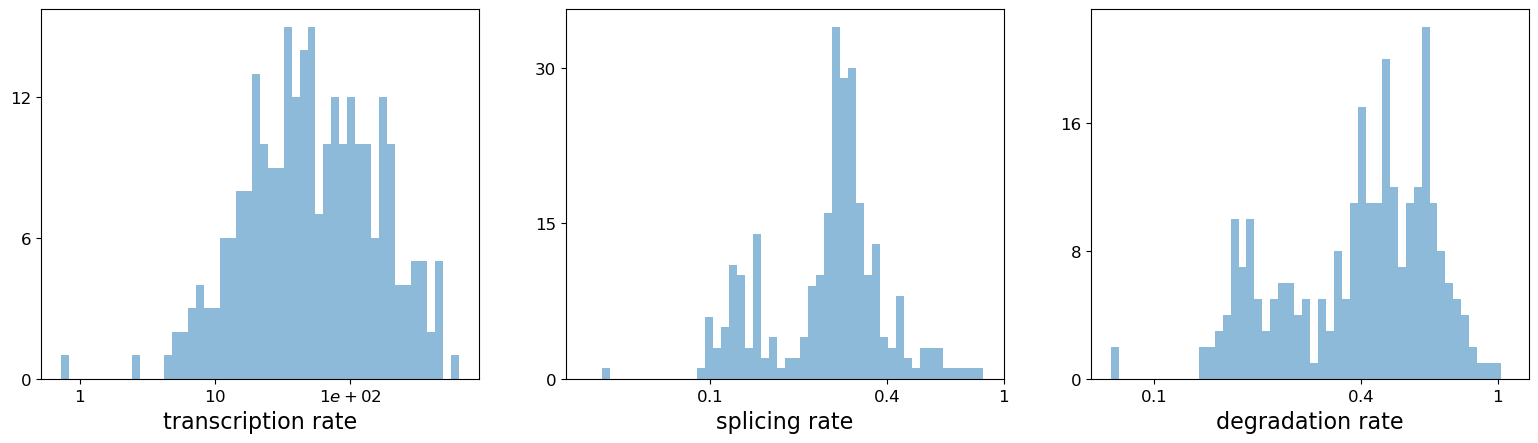

,fit_r2,fit_alpha,fit_beta,fit_gamma,fit_t_,fit_scaling,fit_std_u,fit_std_s,fit_likelihood,fit_u0,fit_s0,fit_pval_steady,fit_steady_u,fit_steady_s,fit_variance,fit_alignment_scaling
0,0.947685,78.892905,0.396832,0.476532,13.310665,0.571928,72.172874,56.786503,1.066159,0.0,0.0,0.498403,187.272808,150.313407,0.047913,1.982734
1,0.867178,226.230347,0.601453,0.765434,13.627937,0.629199,112.019257,84.121399,0.682976,0.0,0.0,0.498625,367.827794,283.013365,0.192942,1.189111
2,0.952033,81.563627,1.001864,0.834815,12.657267,0.396956,30.544258,34.625793,1.062409,0.0,0.0,0.497243,80.504823,93.171358,0.050733,1.131518
3,0.913156,8.187336,0.035167,0.483377,10.351687,8.599413,80.022118,4.652766,0.813359,0.0,0.0,0.492332,231.212267,13.562099,0.071543,1.736044
4,0.969630,16.473735,0.086666,0.321895,18.267079,5.378562,81.095314,17.854284,0.567693,0.0,0.0,0.496719,203.005373,43.855465,0.173006,2.419404


In [98]:
df = adata.var
df = df[(df['fit_likelihood'] > .1) & df['velocity_genes'] == True]
kwargs = dict(xscale='log', fontsize=16)
with scv.GridSpec(ncols=3) as pl:
    pl.hist(df['fit_alpha'], xlabel='transcription rate', **kwargs)
    pl.hist(df['fit_beta'] * df['fit_scaling'], xlabel='splicing rate', xticks=[.1, .4, 1], **kwargs)
    pl.hist(df['fit_gamma'], xlabel='degradation rate', xticks=[.1, .4, 1], **kwargs)

scv.get_df(adata, 'fit*', dropna=True).head()

In [104]:
df_2 = scv.get_df(adata_2, 'fit*', dropna=True).head()

In [109]:
adata_2

AnnData object with n_obs × n_vars = 800 × 300
    obs: 'true_t', 'n_counts', 'leiden', 'velocity_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'spearmans_score', 'velocity_score'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params', 'leiden_colors', 'rank_velocity_genes'
    obsm: 'X_pca', 'X_umap', 'velocity_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'fit_t', 'latent_time_velovi', 'spliced', 'spliced_nuc', 'true_velocity', 'unspliced', 'variance_velocity', 'velocity'
    obsp: 'connectivities', 'distances'

In [108]:
df_2

,fit_alpha,fit_beta,fit_gamma,fit_t_,fit_scaling
0,0.285366,0.315427,0.319966,15.111290,1.0
1,0.324825,0.355882,0.375632,14.144192,1.0
2,0.340708,0.381818,0.372942,13.750994,1.0
3,0.303804,0.348542,0.334934,14.477716,1.0
4,0.319214,0.364773,0.362476,12.150274,1.0


In [101]:
df[['true_t_','fit_t_']]

,true_t_,fit_t_
0,38.232634,13.310665
1,48.473325,13.627937
2,41.504610,12.657267
5,44.289003,11.347119
6,31.303587,22.485876
...,...,...
295,17.990758,8.581597
296,10.190701,8.859769
297,57.655704,13.819764
298,64.590633,15.203607
